In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("height-weight.csv")

In [3]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


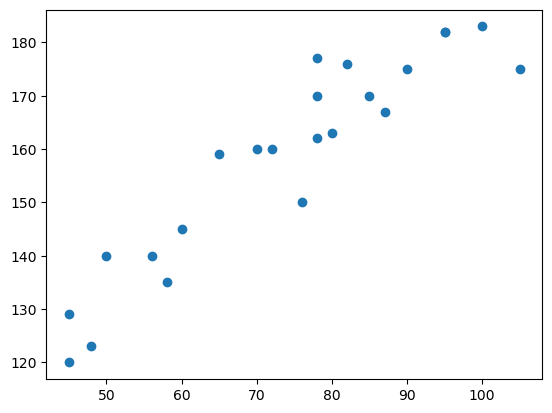

In [6]:
plt.scatter(x='Weight',y='Height',data=df)
plt.show()

In [12]:
x= df[['Weight']]

In [15]:
y = df[['Height']]

In [16]:
y

,Height
0,120
1,135
2,123
3,145
4,160
5,162
6,163
7,175
8,182
9,170


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=1)

In [21]:
y_test

,Height
20,129
17,159
3,145
13,183
19,167
16,140


In [23]:
#scaling standardization >> fit_tranform > train, transform >> test

In [24]:
from sklearn.preprocessing import StandardScaler

In [25]:
scaler = StandardScaler()

In [26]:
x_train = scaler.fit_transform(x_train)

In [ ]:
x_test = scaler.transform(x_test) 

In [28]:
x_test

array([[-1.91781863],
       [-0.678164  ],
       [-0.98807766],
       [ 1.49123159],
       [ 0.68545609],
       [-1.60790497]])

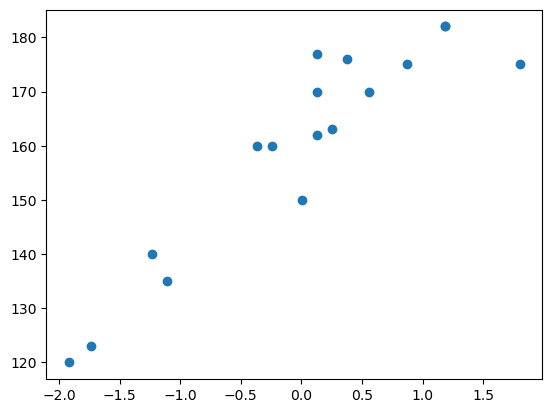

In [29]:
plt.scatter(x_train,y_train)

In [22]:
from sklearn.linear_model import LinearRegression

In [30]:
#linear regression parameters:
#f_intercept: the bestfit line will intercept, by default it is true
#copy_x: copy original x_train data and build model dont modify original data
#n_jobs > processor you want to use all processor 9-1)
#positive :all coefficemnt positive
# after building model , you have attrbute of ythe omodle
#coef  
#intercept/

In [31]:
regressor = LinearRegression()

In [32]:
regressor

LinearRegression()

In [33]:
regressor.fit(x_train,y_train)

LinearRegression()

In [35]:
print("the slope of coef of model ", regressor.coef_)
print("the intercept of model", regressor.intercept_)

the slope of coef of model  [[17.7307072]]
the intercept of model [160.]


In [36]:
regressor.predict(x_train)

array([[166.65863288],
       [153.47066096],
       [129.29271243],
       [160.06464692],
       [164.46063756],
       [175.45061417],
       [140.28268904],
       [169.95562586],
       [125.99571945],
       [162.26264224],
       [155.66865628],
       [138.08469371],
       [162.26264224],
       [180.94560247],
       [191.93557907],
       [180.94560247],
       [162.26264224]])

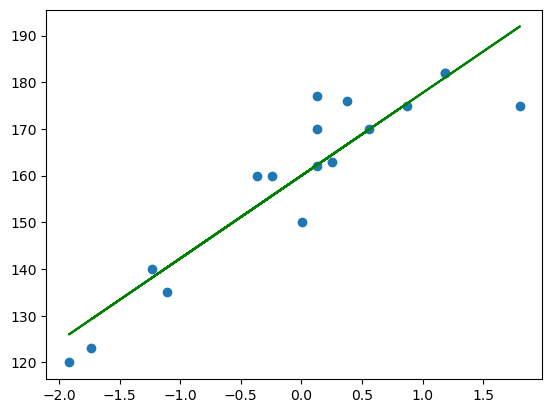

In [37]:
plt.scatter(x_train,y_train)
plt.plot(x_train,regressor.predict(x_train),'g')

In [38]:
#predicted height - intercept + coeff_(wieght)
#y_predict_train = 160.0+17.74

In [39]:
#prediction on test data = intercept + coeff_(wieght)
#y_predict_test = 160.0+17.74*(x_test)

In [40]:
y_predi_test =regressor.predict(x_test)

In [42]:
y_predi_test,y_test

(array([[125.99571945],
        [147.97567266],
        [142.48068436],
        [186.44059077],
        [172.15362118],
        [131.49070775]]),
     Height
 20     129
 17     159
 3      145
 13     183
 19     167
 16     140)

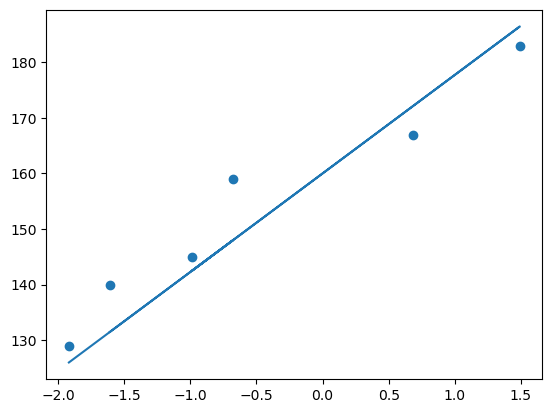

In [43]:
plt.scatter(x_test,y_test)
plt.plot(x_test,y_predi_test)

In [44]:
#performance matrics
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [45]:
mse = mean_squared_error(y_test,y_predi_test)
mae = mean_absolute_error(y_test,y_predi_test)
rmse = np.sqrt(mse)

print(mse,mae,rmse)

41.28566283045539 5.608571289304824 6.4253920371021245


In [46]:
#rsquare - 1-ssr/sst
from sklearn.metrics import r2_score

In [49]:
score = r2_score(y_test,y_predi_test)

In [48]:
#adjusted rsquare
#r2 = 1-[(1-r2)*(n-1)/(n-r-1)]#n is no of obs, k is no predictor

In [50]:
1-(1-score)*(len(y_test)-1)/(len(y_test)- x_test.shape[1]-1)

0.8401295217820762

In [51]:
# to get num of columns
x_test.shape

(6, 1)

In [52]:
ht_scale =scaler.transform([[70]])

c:\Users\TAHERALI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [53]:
ht_scale

array([[-0.36825034]])

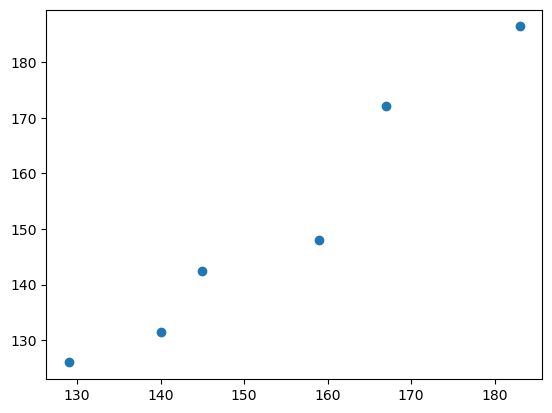

In [54]:
#assumption
#x_y should have linear realtion 
#obseravtion shoud have no relation
#error should have costant variable
#error should be normally distribute
plt.scatter(y_test,y_predi_test)

In [55]:
#ressidual error 
error =y_test - y_predi_test
error

,Height
20,3.004281
17,11.024327
3,2.519316
13,-3.440591
19,-5.153621
16,8.509292


<Axes: ylabel='Count'>

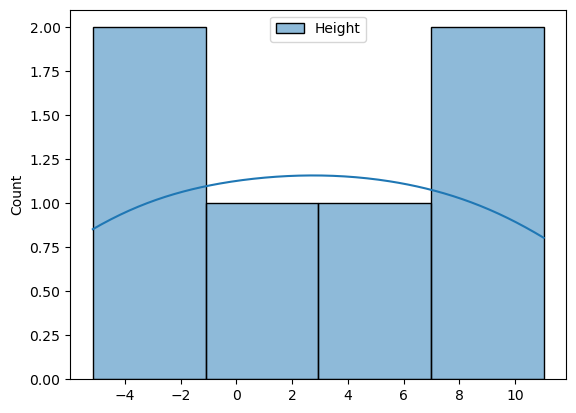

In [57]:
import seaborn as sns
sns.histplot(error,kde=True)

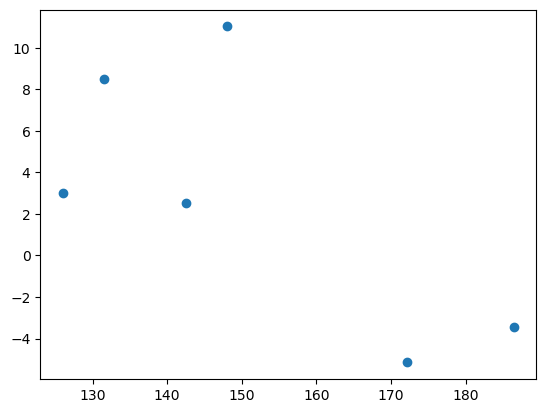

In [58]:
#error should have costant variable
#error should be normally distribute
plt.scatter(y_predi_test,error)